# Lab 3 (Part 2): Categorical Encoding & Multiple Linear Regression
One-hot encoding and multiple regression modeling on the weather dataset.

## Task 1: Load and Explore the Dataset
Load dataset (first 2,000 rows), inspect columns, check nulls, and view summary statistics.

In [45]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load first 2,000 rows
csv_file = glob.glob("*.csv")[0]
df = pd.read_csv(csv_file).head(2000)

print(f"Loaded {len(df)} rows from '{csv_file}'")
print(df.head())

print("\nNull values count:")
print(df.isnull().sum())

print("\nDataset info:")
df.info()

print("\nDescriptive statistics:")
print(df.describe())

Loaded 2000 rows from 'weatherHistory 2.csv'
                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0        

## Task 2: One-Hot Encode Multiple Categorical Features
Convert categorical features (`Precip Type` and `Summary`) to dummy variables using `drop_first=True`.

In [46]:
# One-hot encode multiple categorical columns dropping first category
dummies = pd.get_dummies(df[['Precip Type', 'Summary']], drop_first=True, dtype=int)

# Merge back into main DataFrame
df_encoded = pd.concat([df, dummies], axis=1)

# Print all encoded dummy feature names
print("One-Hot Encoded Features created:")
for col in dummies.columns:
    print(f"- {col}")

# Print at least 3 sample encoded features
print("\nSample of Encoded Features:")
print(dummies[['Precip Type_snow', 'Summary_Mostly Cloudy', 'Summary_Partly Cloudy']].head())

One-Hot Encoded Features created:
- Precip Type_snow
- Summary_Breezy and Overcast
- Summary_Breezy and Partly Cloudy
- Summary_Clear
- Summary_Foggy
- Summary_Humid and Mostly Cloudy
- Summary_Mostly Cloudy
- Summary_Overcast
- Summary_Partly Cloudy

Sample of Encoded Features:
   Precip Type_snow  Summary_Mostly Cloudy  Summary_Partly Cloudy
0                 0                      0                      1
1                 0                      0                      1
2                 0                      1                      0
3                 0                      0                      1
4                 0                      1                      0


## Task 3: Visualize the Impact of Categorical Features
Bar plots showing average temperature across categorical features.

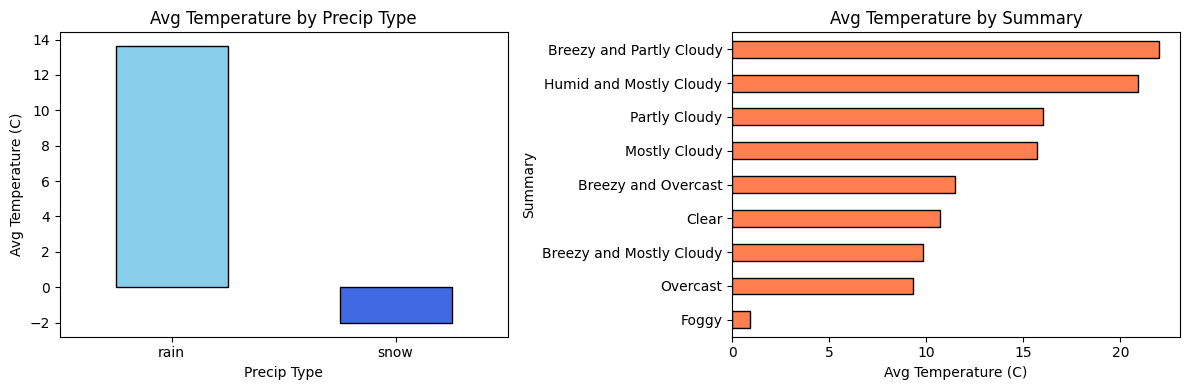

In [47]:
# Bar plots for categorical features vs Temperature
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df.groupby('Precip Type')['Temperature (C)'].mean().plot(kind='bar', color=['skyblue', 'royalblue'], edgecolor='black')
plt.title('Avg Temperature by Precip Type')
plt.xlabel('Precip Type')
plt.ylabel('Avg Temperature (C)')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df.groupby('Summary')['Temperature (C)'].mean().sort_values().plot(kind='barh', color='coral', edgecolor='black')
plt.title('Avg Temperature by Summary')
plt.xlabel('Avg Temperature (C)')
plt.ylabel('Summary')

plt.tight_layout()
plt.show()

## Task 4: Prepare Data for Multiple Linear Regression
Select numerical and one-hot encoded features (X) and target (y), then split into train (80%) and test (20%) sets.

In [48]:
# Select numerical features + all one-hot encoded dummy features
num_cols = ['Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)', 'Visibility (km)']
features = num_cols + dummies.columns.tolist()

X = df_encoded[features]
y = df_encoded['Temperature (C)']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total features: {len(features)}")
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Total features: 13
Train size: 1600 | Test size: 400


## Task 5: Train a Multiple Linear Regression Model
Fit LinearRegression on training data and map feature names to coefficients.

In [49]:
# Fit Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Feature coefficients table
coef_table = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

print(f"Intercept: {model.intercept_:.4f}")
print("\nFeature Coefficients:")
print(coef_table)

Intercept: 37.0803

Feature Coefficients:
                             Feature  Coefficient
0                           Humidity   -23.319845
1                  Wind Speed (km/h)    -0.188432
2               Pressure (millibars)    -0.004809
3                    Visibility (km)     0.296192
4                   Precip Type_snow    -8.216630
5        Summary_Breezy and Overcast     0.136620
6   Summary_Breezy and Partly Cloudy     7.682793
7                      Summary_Clear    -2.772924
8                      Summary_Foggy    -3.969652
9    Summary_Humid and Mostly Cloudy     6.088825
10             Summary_Mostly Cloudy    -0.308811
11                  Summary_Overcast    -3.276659
12             Summary_Partly Cloudy    -1.269933


### Visualization: Feature Coefficients Impact
Bar chart illustrating how each feature positively or negatively affects temperature.

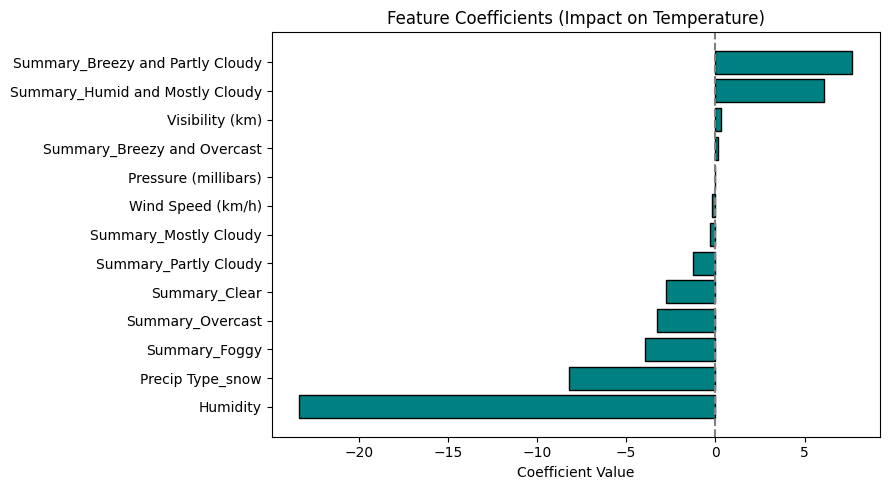

In [50]:
# Bar plot of feature coefficients
plt.figure(figsize=(9, 5))
sorted_coefs = coef_table.sort_values('Coefficient')
plt.barh(sorted_coefs['Feature'], sorted_coefs['Coefficient'], color='teal', edgecolor='black')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Coefficients (Impact on Temperature)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## Task 6: Evaluate the Model
Predict on test data and calculate MSE, RMSE, and R² score.

In [51]:
# Predictions and evaluation
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 27.7380
Root Mean Squared Error (RMSE): 5.2667
R² Score: 0.6130


### Visualization: Actual vs. Predicted Temperature
Scatter plot evaluating model prediction accuracy against perfect fit line.

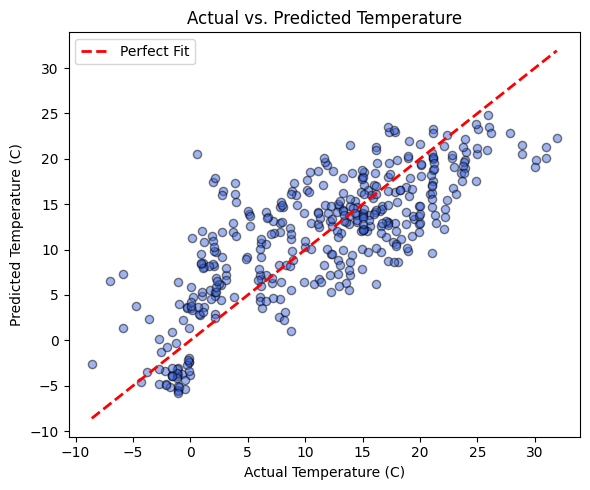

In [52]:
# Scatter plot of Actual vs Predicted Temperature
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.5, edgecolor='black', s=35)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Fit')
plt.title('Actual vs. Predicted Temperature')
plt.xlabel('Actual Temperature (C)')
plt.ylabel('Predicted Temperature (C)')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation
The model achieves an $R^2$ of ~0.61. Humidity, precipitation type (snow), and overcast/foggy weather summaries have the strongest negative influence on temperature.